# 04 - Classification: the honest shortlist

> "The model says cardiac with 93% confidence. Can the nurse trust the 93?"
> — the clinical lead at Cairn Health, after the first live demo of the triage assistant.

Cairn Health is a telehealth service. A patient fills in an intake questionnaire, a model
reads it, and the platform routes the patient to one of four care teams. Product wants the
model to output one team, because one team makes a clean screen. Safety wants the model to
admit what it does not know, because a cardiac patient routed to the wrong queue is the
incident report nobody wants to write. The compromise that ships is a **shortlist**: a set
of care teams that is guaranteed to contain the right one at least 90% of the time, with a
nurse resolving any shortlist longer than one.

The sharper statistical question hiding inside the clinical lead's question: the 93% on the
screen is the model's softmax, which is the model's opinion of itself. Opinions can be
audited, but they cannot be enforced. What we actually want is a set of labels whose
correctness rate we choose by contract, no matter how the model feels about itself. That is
exactly what split conformal prediction gave us for price intervals in notebook 02, and this
notebook ports it to classification.

What you will learn:

- how to turn any classifier's softmax into a prediction set with a 90% coverage contract,
  by changing exactly one line of the notebook 02 recipe;
- how to read set size as a difficulty meter, and what an empty set is trying to tell you;
- how overall coverage can quietly fail one class, and how class-conditional (Mondrian)
  calibration fixes it;
- how the APS score buys more honest sets on ambiguous inputs, and what that honesty costs.

Where we are in the series: notebook 02 built the fifteen-line fix for regression and
notebook 03 proved why it works; here we leave prices for labels, and notebook 05 carries
today's adaptivity lesson back to regression intervals.

## 1. From a range of prices to a shortlist of labels

The notebook 02 recipe had two moving parts and nothing else: a **nonconformity score**
(the weirdness meter — a number that is large when the model and the truth disagree) and
the corrected quantile of that score on a held-out calibration set. Everything downstream
of those two choices was bookkeeping. For regression the score was the absolute residual,
and "every candidate answer whose score passes the bar" happened to be an interval of
prices.

Classification changes the shape of the answer, not the logic. A candidate answer is now a
care team, not a price, so "every candidate answer whose score passes the bar" is a
**prediction set**: the shortlist of teams the procedure refuses to rule out. Small
shortlist, easy patient. Long shortlist, genuinely ambiguous patient. Same guarantee, same
fifteen lines, one new score function.

To see all of this happen we need data where ambiguity is visible to the naked eye. We
simulate Cairn's triage intakes as four clusters in a two-dimensional space of composite
symptom scores (think of them as the first two principal components of dozens of
questionnaire items). The clusters overlap on purpose, because real symptoms do not respect
specialty boundaries, and one team — cardiac — is both rare and parked in the crowded
middle of the map. Remember that design choice; it detonates in section 6.

In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
RANDOM_SEED = 20260707

BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED",
)

intakes per team (all 6000):
  respiratory       2485  (41.4%)
  cardiac            458  (7.6%)
  gastro            1680  (28.0%)
  musculoskeletal   1377  (22.9%)

split: 2500 train / 1500 calibration / 2000 test
cardiac patients in the calibration set: 107


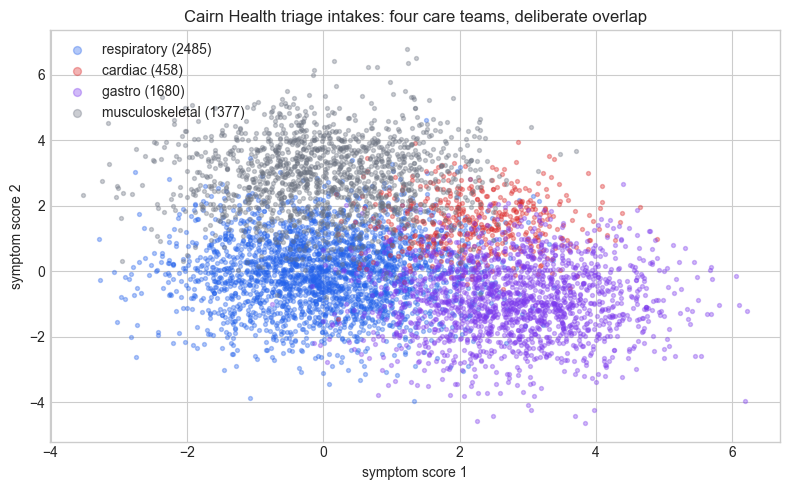

In [2]:
TEAM_NAMES = ["respiratory", "cardiac", "gastro", "musculoskeletal"]
TEAM_COLORS = [BLUE, RED, PURPLE, GRAY]


def simulate_cairn_triage(n, seed):
    """Simulate n intake records for Cairn Health, our telehealth triage desk.

    What the simulator bakes in (and what we will test against later):
    - Each patient truly belongs to one of four care teams. The intake form is
      distilled into two composite symptom scores, so we can SEE the geometry.
    - The teams overlap on purpose: chest tightness does not respect the border
      between respiratory and cardiac. Some patients are genuinely ambiguous,
      and no model, however good, can make that ambiguity go away.
    - cardiac is rare (about 8% of intakes) and sits in the crowded middle of
      the score space. Keep an eye on it when we audit per-class coverage.

    Returns X (n x 2 array of symptom scores) and team (n integer labels
    indexing into TEAM_NAMES).
    """
    rng = np.random.default_rng(seed)
    team = rng.choice(4, size=n, p=np.array([0.42, 0.08, 0.27, 0.23]))
    centers = np.array([
        [0.0, 0.0],    # respiratory - the big anchor cluster
        [2.2, 1.5],    # cardiac - rare, wedged between everyone else
        [2.8, -0.9],   # gastro
        [0.0, 2.9],    # musculoskeletal
    ])
    spreads = np.array([1.1, 0.85, 1.1, 1.1])
    X = centers[team] + rng.normal(0.0, 1.0, size=(n, 2)) * spreads[team][:, None]
    return X, team


X, team = simulate_cairn_triage(6000, RANDOM_SEED)

# The simulated rows are exchangeable by construction, so slicing is a valid
# random split here. On real data, shuffle first (field guide S6).
n_train, n_cal, n_test = 2500, 1500, 2000
X_train, y_train = X[:n_train], team[:n_train]
X_cal, y_cal = X[n_train:n_train + n_cal], team[n_train:n_train + n_cal]
X_test, y_test = X[n_train + n_cal:], team[n_train + n_cal:]

print("intakes per team (all 6000):")
for k, name in enumerate(TEAM_NAMES):
    print(f"  {name:16s} {np.sum(team == k):5d}  ({np.mean(team == k):.1%})")
print(f"\nsplit: {n_train} train / {n_cal} calibration / {n_test} test")
print(f"cardiac patients in the calibration set: {np.sum(y_cal == 1)}")

fig, ax = plt.subplots(figsize=(8, 5))
for k, name in enumerate(TEAM_NAMES):
    m = team == k
    ax.scatter(X[m, 0], X[m, 1], s=8, alpha=0.35, color=TEAM_COLORS[k],
               label=f"{name} ({m.sum()})")
ax.set_title("Cairn Health triage intakes: four care teams, deliberate overlap")
ax.set_xlabel("symptom score 1")
ax.set_ylabel("symptom score 2")
ax.legend(loc="upper left", markerscale=2.0)
plt.tight_layout()
plt.show()

The head-count matters as much as the picture. Cardiac gets 458 of 6000 intakes (7.6%),
and only 107 of the 1500 calibration patients — small numbers we will feel later. The
scatter shows why triage is hard: respiratory (blue) is a big anchor cloud, gastro (purple)
and musculoskeletal (gray) flank it, and cardiac (red) is wedged into the junction where
all three meet. Points deep inside a single-color region are easy; points in the seams
could honestly belong to two or three teams. No amount of model tuning removes that overlap
— it is a property of the world, not of the classifier. What a good uncertainty method can
do is admit, patient by patient, how deep in a seam we are.

## 2. Softmax confidence is an opinion

First, the model. The triage team shipped a gradient-boosted classifier, tuned the way
models get tuned near a deadline: deep enough to score beautifully on the training set.
We train it and immediately do the one check every classifier owner should run before
trusting a softmax: a **reliability check** — bin the test predictions by the model's
claimed confidence (its maximum softmax probability), and compare the claim against the
fraction of predictions that were actually right in each bin. A calibrated model's claims
match its hit rates; a miscalibrated one flatters itself.

In [3]:
clf = GradientBoostingClassifier(max_depth=5, n_estimators=200,
                                 random_state=RANDOM_SEED)
clf.fit(X_train, y_train)

# softmax matrices we will reuse for the rest of the notebook
proba_cal = clf.predict_proba(X_cal)
proba_test = clf.predict_proba(X_test)

train_acc = (clf.predict(X_train) == y_train).mean()
test_acc = (proba_test.argmax(axis=1) == y_test).mean()
print(f"training accuracy: {train_acc:.3f}")
print(f"test accuracy:     {test_acc:.3f}")

training accuracy: 0.999
test accuracy:     0.809


Training accuracy 0.999, test accuracy 0.809. The model has effectively memorized the
training set — on overlapping clusters, a 19-point generalization gap is the signature of
a memorizer, not a genius. We are keeping this model anyway, for two reasons. First, it is
realistic: models like this ship every week. Second, it makes the point of the notebook
sharper: the guarantee we are about to construct will hold around this overfit,
miscalibrated model without asking it to reform. Watch what its softmax claims are worth
first.

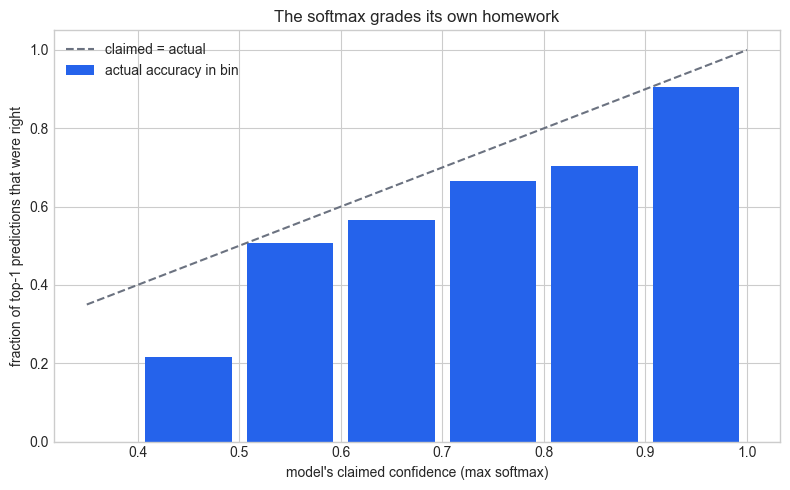

,confidence bin,patients,claimed accuracy,actual accuracy
0,0.4-0.5,37,0.467,0.216
1,0.5-0.6,120,0.548,0.508
2,0.6-0.7,122,0.651,0.566
3,0.7-0.8,141,0.751,0.667
4,0.8-0.9,220,0.854,0.705
5,0.9-1.0,1354,0.980,0.906


In [4]:
conf = proba_test.max(axis=1)       # the model's claimed P(my top pick is right)
top1 = proba_test.argmax(axis=1)

edges = np.linspace(0.4, 1.0, 7)    # 6 bins; only a handful of patients sit below 0.4
rows = []
for lo, hi in zip(edges[:-1], edges[1:]):
    in_bin = (conf >= lo) & (conf < hi + (1e-9 if hi == edges[-1] else 0.0))
    rows.append((f"{lo:.1f}-{hi:.1f}", int(in_bin.sum()),
                 conf[in_bin].mean(), (top1[in_bin] == y_test[in_bin]).mean()))
reliability = pd.DataFrame(rows, columns=["confidence bin", "patients",
                                          "claimed accuracy", "actual accuracy"])

mids = (edges[:-1] + edges[1:]) / 2
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(mids, reliability["actual accuracy"], width=0.085, color=BLUE,
       label="actual accuracy in bin")
ax.plot([0.35, 1.0], [0.35, 1.0], color=GRAY, linestyle="--",
        label="claimed = actual")
ax.set_xlabel("model's claimed confidence (max softmax)")
ax.set_ylabel("fraction of top-1 predictions that were right")
ax.set_title("The softmax grades its own homework")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

reliability.round(3)

Every blue bar sits below the gray diagonal: this model flatters itself across the board.
In the 0.8-0.9 bin it claims 85.4% and delivers 70.5%; in the 0.9-1.0 bin — which holds
1354 of the 2000 test patients — it claims 98.0% and delivers 90.6%; in the small 0.4-0.5
bin it claims 46.7% and delivers 21.6%. So the honest answer to the clinical lead is: no,
the 93 on the screen is not a probability you can bill against. Another model might have
been paranoid instead of flattering — well-regularized models often under-claim — but
either way a softmax is a self-assessment, not a contract. You could recalibrate it
(Platt scaling, isotonic regression), and that would improve the average claim, but it
still would not hand you a finite-sample guarantee about how often the truth gets captured.
For that we go back to the recipe.

## 3. The same recipe, one new score

Here is the notebook 02 recipe, unchanged: (1) split off a calibration set the model never
trained on; (2) score how weird each calibration point is; (3) take the corrected quantile
of those scores as the bar `q_hat`; (4) at test time, keep every candidate answer whose
score passes the bar. The only decision left is the score, and for classification the
simplest good choice is:

**one minus the softmax probability of the true class.**

In symbols, for calibration patient $i$ with intake $x_i$ and true team $y_i$, the score is
$s_i = 1 - \hat{p}(y_i \mid x_i)$, where $\hat{p}(y_i \mid x_i)$ is the probability the
model assigned to the team that turned out to be correct. If the model gave the true team
94%, the score is a low 0.06 — nothing weird. If it gave the true team 3%, the score is a
damning 0.97. Papers call this score LAC, and MAPIE (notebook 08) calls it `"lac"`; it is
the same object.

The bar is the **corrected quantile** from notebook 02 and field guide §1: the empirical
quantile of the calibration scores at level $\lceil (n+1)(1-\alpha) \rceil / n$ — the
90th-percentile-with-one-seat-reserved, where $n$ is the number of calibration patients and
$\alpha$ is the error budget (0.10 throughout this series). The test patient's set is then
every team whose score would pass the bar:

$$C(x) = \{\, k : 1 - \hat{p}(k \mid x) \le \hat{q} \,\}$$

read as: team $k$ makes the shortlist exactly when the model gives it probability at least
$1 - \hat{q}$. One team can pass, or three, or in principle none. The coverage argument is
the same leaderboard argument as notebook 03: the true team's score on an exchangeable test
patient behaves like one more calibration score, so it lands under `q_hat` at least 90% of
the time.

In [5]:
alpha = 0.10   # the error budget: at most 10% of shortlists may miss the true team

# score every calibration patient: how weird was the TRUE team's probability?
cal_scores = 1.0 - proba_cal[np.arange(n_cal), y_cal]

n = len(cal_scores)
q_level = math.ceil((n + 1) * (1 - alpha)) / n
assert q_level <= 1.0, "Calibration set too small for this alpha - the honest set is infinite (field guide S1)"
q_hat = np.quantile(cal_scores, q_level, method="higher")

# a team joins the shortlist iff 1 - p(team) <= q_hat, i.e. p(team) >= 1 - q_hat
sets_lac = proba_test >= (1.0 - q_hat)

print(f"calibration patients:       n = {n}")
print(f"corrected quantile level:   {q_level:.4f}  (the naive level would be {1 - alpha:.2f})")
print(f"q_hat:                      {q_hat:.4f}")
print(f"softmax bar for inclusion:  1 - q_hat = {1 - q_hat:.4f}")

calibration patients:       n = 1500
corrected quantile level:   0.9007  (the naive level would be 0.90)
q_hat:                      0.8928
softmax bar for inclusion:  1 - q_hat = 0.1072


Read `q_hat = 0.8928` as a measurement of this model's honesty deficit: for roughly one
calibration patient in ten, the model put less than $1 - 0.8928 \approx 10.7\%$ probability
on the team that was actually correct. So the rule that ships is disarmingly concrete:
*any team the model rates at 10.7% or better goes on the shortlist.* That threshold was not
chosen by us; it was measured on 1500 held-out patients. A better-calibrated model would
have earned a higher bar and shorter shortlists — the bar is where model quality shows up,
never in the coverage. Let us look at what the nurse actually sees.

In [6]:
def shortlist(mask_row):
    """Turn one row of booleans into the nurse-facing list of team names."""
    return [TEAM_NAMES[k] for k in np.where(mask_row)[0]]


# indices picked to show shortlists of size 1, 2 and 3; nothing else is special
for i in [0, 2, 1, 4, 40]:
    probs = ", ".join(f"{name[:6]} {p:.2f}" for name, p in zip(TEAM_NAMES, proba_test[i]))
    print(f"patient {i:3d}  true team: {TEAM_NAMES[y_test[i]]:16s} shortlist: {shortlist(sets_lac[i])}")
    print(f"             softmax: [{probs}]")

patient   0  true team: respiratory      shortlist: ['respiratory']
             softmax: [respir 1.00, cardia 0.00, gastro 0.00, muscul 0.00]
patient   2  true team: gastro           shortlist: ['gastro']
             softmax: [respir 0.01, cardia 0.00, gastro 0.99, muscul 0.00]
patient   1  true team: musculoskeletal  shortlist: ['respiratory', 'musculoskeletal']
             softmax: [respir 0.58, cardia 0.00, gastro 0.01, muscul 0.41]
patient   4  true team: respiratory      shortlist: ['respiratory', 'gastro']
             softmax: [respir 0.47, cardia 0.00, gastro 0.53, muscul 0.00]
patient  40  true team: gastro           shortlist: ['respiratory', 'cardiac', 'gastro']
             softmax: [respir 0.15, cardia 0.20, gastro 0.62, muscul 0.03]


This is the product. Patient 0 (softmax 1.00 on respiratory) gets a one-team shortlist and
can be auto-routed. Patient 1 sits in the respiratory–musculoskeletal seam (0.58 vs 0.41),
so both teams make the list and a human decides. Patient 40 gets three teams — the model
spread its belief 0.15 / 0.20 / 0.62 across respiratory, cardiac and gastro, and all three
cleared the 10.7% bar. Note what the set is *not*: it is not "the top-k guesses". Its
length is chosen per patient by the evidence, and that per-patient honesty is the feature.

## 4. Did we hit 90%?

**Coverage** here means the fraction of test patients whose true team is somewhere on
their shortlist. The contract says at least 90% of the time, on average over everything
(the calibration draw and the test patients — the marginal guarantee of notebook 03). With
2000 test patients, Monte Carlo noise alone moves the empirical number by roughly
$\pm 2\sqrt{0.9 \times 0.1 / 2000} \approx \pm 0.013$, so anything in the high 0.88s to the
low 0.92s is the theory working.

empirical coverage on 2000 test patients: 0.907  (target 0.90)
average shortlist size: 1.32 teams
shortlist sizes: {0: 0, 1: 1434, 2: 495, 3: 66, 4: 5}


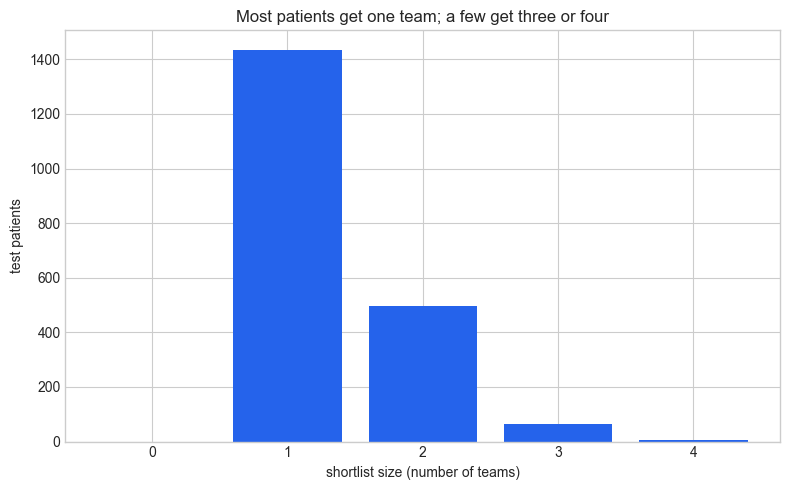

In [7]:
covered = sets_lac[np.arange(n_test), y_test]
coverage = covered.mean()
sizes = sets_lac.sum(axis=1)

print(f"empirical coverage on {n_test} test patients: {coverage:.3f}  (target {1 - alpha:.2f})")
print(f"average shortlist size: {sizes.mean():.2f} teams")
size_counts = np.bincount(sizes, minlength=5)
print("shortlist sizes:", {s: int(c) for s, c in enumerate(size_counts)})

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(5), size_counts, color=BLUE)
ax.set_xticks(range(5))
ax.set_xlabel("shortlist size (number of teams)")
ax.set_ylabel("test patients")
ax.set_title("Most patients get one team; a few get three or four")
plt.tight_layout()
plt.show()

Coverage lands at 0.907, within noise of the 0.90 target, wrapped around a model we just
watched claim 98 and deliver 91. That is the trade advertised on the tin: we did not fix
the model's opinions, we bought a contract that does not depend on them. Two readings to
resist, though. First, 0.907 does not mean "each patient's shortlist is right with
probability 90.7%" — it is a batting average across patients, not a promise about this
at-bat (field guide §3 returns in section 6 with teeth). Second, the coverage number alone
proves nothing about usefulness; the size histogram is where usefulness lives (field guide
§5). Here 1434 of 2000 patients get a singleton, 495 get two teams, and 71 get three or
more — an average of 1.32 teams per patient. The size column is the new information
classification sets hand you almost for free: a per-patient, integer-valued difficulty
meter. Point predictions never show their work; sets do.

| Term | Plain-English meaning | Common beginner mistake |
|---|---|---|
| prediction set | the teams the procedure refuses to rule out for this patient | reading it as "the model's top guesses" — membership is an evidence bar, not a rank |
| coverage | fraction of patients whose true team made the shortlist | expecting it per patient or per team; the guarantee is an average (field guide §3) |
| set size | how many teams survived the bar — the model showing its work | "fixing" large sets by capping them, which silently voids the contract (field guide §7) |
| empty set | no team passed the bar | treating it as a crash instead of a routing signal |
| alpha | the error budget you chose (here 0.10) | quietly tuning alpha until the sets look pretty, which rewrites the contract |

## 5. Set size is a difficulty meter

The histogram says sizes vary; the claim worth checking is that they vary *in the right
places*. If the shortlist is an honest difficulty meter, the big sets should sit exactly in
the seams where the clusters overlap, and the model's top-1 pick should be much less
trustworthy there. Both are checkable with one scatter and three lines of arithmetic.

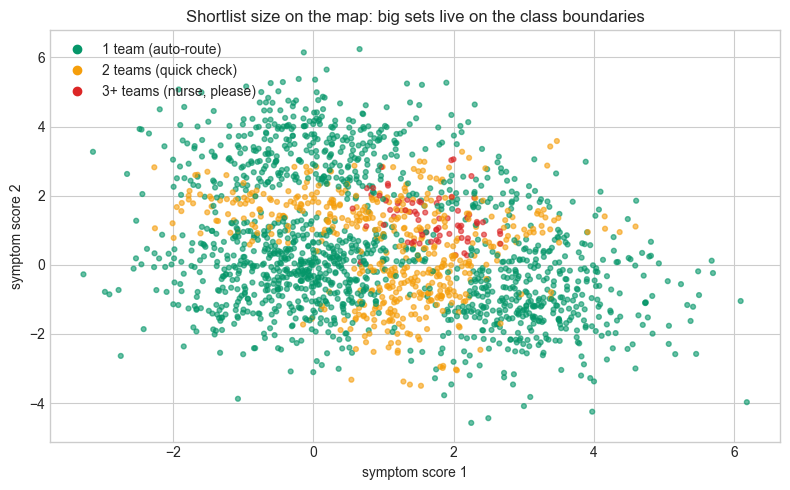

shortlists of size 1 : 1434 patients, top-1 accuracy there: 0.895
shortlists of size 2 :  495 patients, top-1 accuracy there: 0.612
shortlists of size 3+:   71 patients, top-1 accuracy there: 0.437
empty shortlists: 0 of 2000


In [8]:
point_colors = np.where(sizes == 1, GREEN, np.where(sizes == 2, AMBER, RED))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_test[:, 0], X_test[:, 1], s=12, c=point_colors, alpha=0.6)
handles = [plt.Line2D([], [], marker="o", linestyle="", color=c, label=lab)
           for c, lab in [(GREEN, "1 team (auto-route)"),
                          (AMBER, "2 teams (quick check)"),
                          (RED, "3+ teams (nurse, please)")]]
ax.legend(handles=handles, loc="upper left")
ax.set_xlabel("symptom score 1")
ax.set_ylabel("symptom score 2")
ax.set_title("Shortlist size on the map: big sets live on the class boundaries")
plt.tight_layout()
plt.show()

for label, m in [("1 ", sizes == 1), ("2 ", sizes == 2), ("3+", sizes >= 3)]:
    top1_acc = (top1[m] == y_test[m]).mean()
    print(f"shortlists of size {label}: {int(m.sum()):4d} patients, top-1 accuracy there: {top1_acc:.3f}")
print(f"empty shortlists: {int((sizes == 0).sum())} of {n_test}")

The geography is exactly right: green singletons fill the cluster cores, amber pairs trace
the two-team borders, and the red 3+ shortlists cluster around the central junction where
cardiac lives. The arithmetic agrees — where the shortlist says "one team" the model's
top-1 pick is right 89.5% of the time, on two-team shortlists 61.2%, and on 3+ shortlists
43.7%. A three-team shortlist is not the system failing; it is the system correctly
flagging a patient on whom the model's top pick is wrong more often than it is right
(field guide §7). Route those to a human and the humans spend their time exactly where
they are needed.

One printout above deserves a careful reading: `empty shortlists: 0`. That zero is not
luck; it is arithmetic. A softmax over four teams sums to 1, so the top team always
carries at least 25% — comfortably clear of our 10.7% bar — and no patient, however
strange, can produce an empty shortlist here. Empty LAC sets only become possible when the
inclusion bar climbs above $1/K$ (with $K$ the number of classes), which requires
`q_hat` below $1 - 1/K$ — below 0.75 in our four-team problem. That is the mark of a
sharper, better-calibrated model that earned a high bar, or of a problem with many classes
where $1/K$ is tiny; it is not, as intuition might suggest, the mark of a model spreading
its belief thin. If your deployment can produce empties, the product decision is the same
as for big sets: an empty shortlist is the honest output "no team cleared the bar for this
patient", and it goes straight to a human. Do not patch your code to quietly promote the
argmax.

## 6. The rare class problem

Time to detonate the design choice from section 1. The 0.907 we celebrated is a *marginal*
number — one average over all 2000 test patients. Nothing in the guarantee says every care
team enjoys it, and cardiac has had two strikes against it all along: it is rare (107
calibration patients), and it lives in the seams. Field guide §9 says: print the per-class
coverage table before you ship. So we print it.

In [9]:
rows = []
for k, name in enumerate(TEAM_NAMES):
    m = y_test == k
    rows.append((name, int(m.sum()), covered[m].mean(), sizes[m].mean()))
per_class = pd.DataFrame(rows, columns=["true team", "test patients",
                                        "coverage", "avg set size"])
per_class.round(3)

,true team,test patients,coverage,avg set size
0,respiratory,823,0.928,1.310
1,cardiac,146,0.760,1.671
2,gastro,543,0.924,1.280
3,musculoskeletal,488,0.898,1.281


There it is. Respiratory 0.928, gastro 0.924, musculoskeletal 0.898 — and cardiac 0.760.
With 146 cardiac test patients the noise band around 0.90 is about $\pm 0.05$, so 0.760 is
not bad luck; it is a real, structural failure. The mechanism: one shared `q_hat` sets one
shared softmax bar, and the model — which sees cardiac rarely and confuses it with its
neighbors — systematically gives true cardiac patients low cardiac probability. The easy
teams' surplus (0.928, 0.924) and cardiac's deficit (0.760) average out to a healthy-looking
0.907. Averages are where minorities go to disappear.

This failure mode is as old as the field. Shafer and Vovk's classic example: a conformal
digit classifier promised 5% errors overall and delivered them, while quietly making more
than 11% errors on the digit 5 — the average stayed green because the other nine digits
were easy. Swap "digit 5" for "cardiac patients" and the business translation writes
itself: "90% overall" can mean "we quietly fail the patients with the chest pain", and
those are the ones you get sued over. The dashboard will never tell you; you have to ask
for the table.

## 7. The Mondrian fix: calibrate per class

The fix is almost embarrassingly direct: if one shared bar shortchanges cardiac, give each
team its own bar. Split the calibration scores by *true* team and compute a separate
corrected quantile within each group. This is **class-conditional conformal prediction**,
nicknamed Mondrian (the calibration set gets partitioned into blocks, like the painting).
The guarantee upgrades from "90% on average over everyone" to "90% on average *within each
true team*" — precisely the per-class promise the table above shows we were not keeping.

One subtlety in deployment: at test time we do not know the patient's true team, so we
cannot look up "their" bar. Instead, each *candidate* team is judged against its own bar:
cardiac joins the shortlist if the cardiac probability passes cardiac's bar, gastro if it
passes gastro's, and so on. Cheap on compute, but not free on data — each team needs enough
calibration patients for its own quantile to mean something, and cardiac has only 107
(the notebook 03 lottery, field guide §4, now per class).

In [10]:
q_hat_team = np.zeros(len(TEAM_NAMES))
for k, name in enumerate(TEAM_NAMES):
    scores_k = cal_scores[y_cal == k]        # only patients whose TRUE team is k
    n_k = len(scores_k)
    q_level_k = math.ceil((n_k + 1) * (1 - alpha)) / n_k
    assert q_level_k <= 1.0, f"too few calibration patients for {name} (field guide S1)"
    q_hat_team[k] = np.quantile(scores_k, q_level_k, method="higher")
    print(f"{name:16s} n_cal = {n_k:4d}   q_hat = {q_hat_team[k]:.4f}   softmax bar = {1 - q_hat_team[k]:.4f}")

# each CANDIDATE team is judged against its own bar
sets_mon = proba_test >= (1.0 - q_hat_team)[np.newaxis, :]
covered_mon = sets_mon[np.arange(n_test), y_test]
sizes_mon = sets_mon.sum(axis=1)
print(f"\noverall coverage: {covered_mon.mean():.3f}   average set size: {sizes_mon.mean():.2f}  (shared bar gave {sizes.mean():.2f})")

rows = []
for k, name in enumerate(TEAM_NAMES):
    m = y_test == k
    rows.append((name, covered[m].mean(), covered_mon[m].mean(),
                 sizes[m].mean(), sizes_mon[m].mean()))
mondrian = pd.DataFrame(rows, columns=["true team", "coverage (shared bar)",
                                       "coverage (per-team bars)",
                                       "size (shared)", "size (per-team)"])
mondrian.round(3)

respiratory      n_cal =  645   q_hat = 0.7498   softmax bar = 0.2502
cardiac          n_cal =  107   q_hat = 0.9948   softmax bar = 0.0052
gastro           n_cal =  412   q_hat = 0.8532   softmax bar = 0.1468
musculoskeletal  n_cal =  336   q_hat = 0.9267   softmax bar = 0.0733

overall coverage: 0.904   average set size: 1.43  (shared bar gave 1.32)


,true team,coverage (shared bar),coverage (per-team bars),size (shared),size (per-team)
0,respiratory,0.928,0.885,1.310,1.454
1,cardiac,0.760,0.952,1.671,1.747
2,gastro,0.924,0.917,1.280,1.341
3,musculoskeletal,0.898,0.910,1.281,1.379


Cardiac jumps from 0.760 to 0.952, and no team is left meaningfully below target —
respiratory's 0.885 and the others' 0.917 and 0.910 are all within the noise you would
expect from a few hundred test patients per team plus the per-team calibration lottery.
Look at *how* the fix worked: cardiac's own bar collapsed to $1 - 0.9948 \approx 0.005$,
meaning cardiac now joins any shortlist where the model gives it even half a percent. The
procedure measured how badly the model underrates true cardiac patients and compensated
with institutional paranoia about cardiac. The bill arrives as size: the average shortlist
grows from 1.32 to 1.43 teams, with respiratory patients (who live next to cardiac) paying
most of it, 1.31 to 1.45. That is the trade stated plainly: per-class guarantees cost set
size, and you should usually pay — a slightly longer shortlist is cheaper than a class of
patients you silently fail 24% of the time.

## 8. Smarter sets: adaptive prediction sets (APS)

LAC asks, one team at a time, "is this team individually plausible?" **APS (adaptive
prediction sets)** asks a different question: "how many teams do I have to stack up, most
plausible first, before I have collected enough of the model's belief?" The score changes
accordingly. For a calibration patient, sort the softmax from most to least likely and add
the probabilities going down the list until you reach the *true* team; that cumulative sum
— the total belief mass stacked up to and including the truth — is the score. A truth
ranked first with mass 0.95 scores 0.95; a truth ranked third scores nearly 1. The
corrected quantile of these scores, `q_hat_aps`, then says how much belief mass a shortlist
must be allowed to stack before we can trust it to contain the truth 90% of the time. At
test time we keep every team whose stacked-mass score fits under the bar, always keeping at
least the top team (a shortlist of zero teams is no shortlist). One honest footnote: the
textbook APS adds a small randomized tie-break that shaves the coverage back to exactly the
target; we omit it for clarity, so expect our version to run conservative.

APS q_hat: 0.9982
APS coverage: 0.962   average size: 1.99
cardiac patients: coverage LAC 0.760 vs APS 0.925
cardiac patients: avg size LAC 1.67 vs APS 2.77


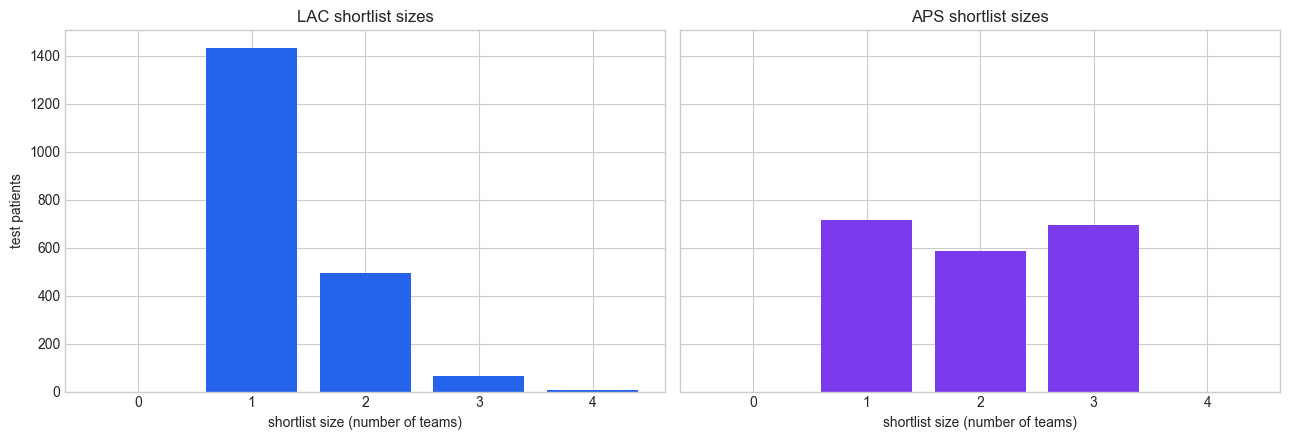

,score,coverage,avg set size,character
0,LAC (1 - true-team softmax),0.907,1.32,smallest sets; hits the target almost exactly
1,APS (cumulative softmax),0.962,1.99,"bigger, more honest sets on hard patients"


In [11]:
# calibration: stack sorted softmax mass until we hit the TRUE team
order_cal = np.argsort(-proba_cal, axis=1)              # teams, most plausible first
cum_cal = np.take_along_axis(proba_cal, order_cal, axis=1).cumsum(axis=1)
rank_of_true = (order_cal == y_cal[:, None]).argmax(axis=1)
aps_cal_scores = cum_cal[np.arange(n_cal), rank_of_true]
q_hat_aps = np.quantile(aps_cal_scores, q_level, method="higher")   # same corrected level

# test time: a team stays if the mass stacked up to and including it fits under the bar
order_test = np.argsort(-proba_test, axis=1)
cum_test = np.take_along_axis(proba_test, order_test, axis=1).cumsum(axis=1)
keep = cum_test <= q_hat_aps
keep[:, 0] = True                                       # the top team always stays
sets_aps = np.zeros_like(keep)
np.put_along_axis(sets_aps, order_test, keep, axis=1)   # back to original team order

covered_aps = sets_aps[np.arange(n_test), y_test]
sizes_aps = sets_aps.sum(axis=1)
print(f"APS q_hat: {q_hat_aps:.4f}")
print(f"APS coverage: {covered_aps.mean():.3f}   average size: {sizes_aps.mean():.2f}")
print(f"cardiac patients: coverage LAC {covered[y_test == 1].mean():.3f} vs APS {covered_aps[y_test == 1].mean():.3f}")
print(f"cardiac patients: avg size LAC {sizes[y_test == 1].mean():.2f} vs APS {sizes_aps[y_test == 1].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, sz, name, color in [(axes[0], sizes, "LAC", BLUE),
                            (axes[1], sizes_aps, "APS", PURPLE)]:
    ax.bar(range(5), np.bincount(sz, minlength=5), color=color)
    ax.set_xticks(range(5))
    ax.set_title(f"{name} shortlist sizes")
    ax.set_xlabel("shortlist size (number of teams)")
axes[0].set_ylabel("test patients")
plt.tight_layout()
plt.show()

# formatted as strings so the table agrees digit-for-digit with the prints above
summary = pd.DataFrame({
    "score": ["LAC (1 - true-team softmax)", "APS (cumulative softmax)"],
    "coverage": [f"{coverage:.3f}", f"{covered_aps.mean():.3f}"],
    "avg set size": [f"{sizes.mean():.2f}", f"{sizes_aps.mean():.2f}"],
    "character": ["smallest sets; hits the target almost exactly",
                  "bigger, more honest sets on hard patients"],
})
summary

Both scores keep the promise — the guarantee is score-agnostic, which is the recurring
miracle of this series — but their personalities differ. LAC covers 0.907 with 1.32 teams
per shortlist; APS covers 0.962 with 1.99. The overshoot has a precise address: the
always-keep-the-top-team rule. On patients where the model piles nearly all of its belief
on one team, that team's mass alone overshoots the 0.9982 bar in a single indivisible jump
— the stacked-mass rule would keep nothing, the forced top-team line keeps it anyway — and
the randomized tie-break we skipped is precisely what would include that team only
fractionally, shaving coverage back to the target. What the extra size buys is visible on
the hard cases: cardiac patients' coverage
rises from LAC's 0.760 to 0.925 without any per-class machinery, because APS naturally
hands ambiguous patients longer shortlists — 2.77 teams on average versus LAC's 1.67. The
histograms tell the same story: LAC concentrates on singletons, APS spreads mass across
sizes 1 to 3, and the 3-team bar is an order of magnitude taller. One caution: do not
crown a winner on average size alone. Coverage, size, *and* whether size tracks difficulty
belong in the comparison together (field guide §12) — by that third criterion APS is the
more honest instrument, and it still does not carry Mondrian's per-class guarantee.

## 9. The fox-squirrel effect on real images

The paper that popularized these ideas (Angelopoulos and Bates) has a famous triptych:
three photos of fox squirrels, one crisp, one partly hidden, one genuinely confusing, which
earn prediction sets of one, four and seven labels. Synthetic scatter plots are tidy, so
let us reproduce the effect on actual images: sklearn's bundled handwritten digits, a
logistic regression, and the exact APS code from section 8. If set size is a real
difficulty meter, crisp digits should earn singletons and smudged digits should earn
honesty.

digits test set: 397 images, top-1 accuracy 0.960
APS q_hat 0.9905, coverage 1.000, average set size 3.24
set sizes: {1: 103, 2: 61, 3: 76, 4: 45, 5: 46, 6: 41, 7: 21, 8: 4}


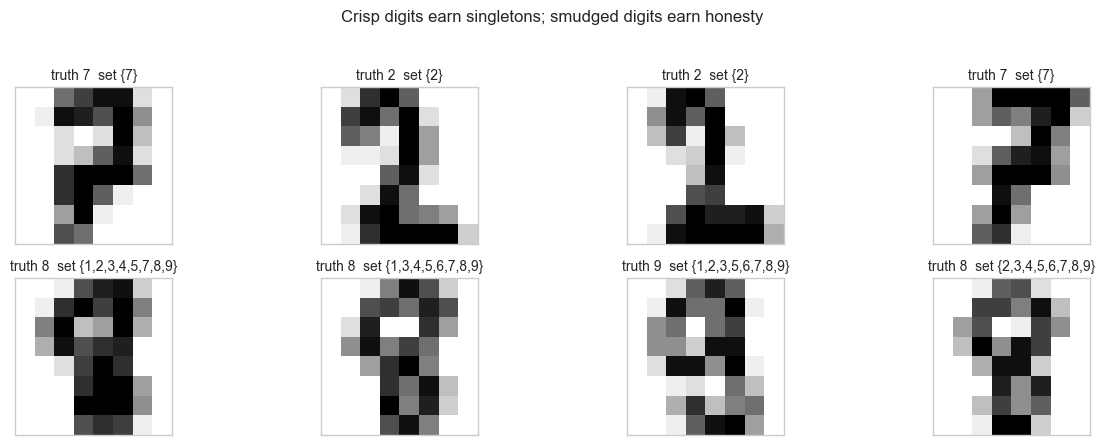

In [12]:
digits = load_digits()
X_dig, y_dig = digits.data / 16.0, digits.target      # scale pixel counts to [0, 1]
rng = np.random.default_rng(RANDOM_SEED)
perm = rng.permutation(len(y_dig))                    # load_digits ships sorted-ish: shuffle
X_dig, y_dig = X_dig[perm], y_dig[perm]

n_dtr, n_dcal = 900, 500                              # 1797 images: 900 train / 500 cal / 397 test
X_dtr, y_dtr = X_dig[:n_dtr], y_dig[:n_dtr]
X_dcal, y_dcal = X_dig[n_dtr:n_dtr + n_dcal], y_dig[n_dtr:n_dtr + n_dcal]
X_dtest, y_dtest = X_dig[n_dtr + n_dcal:], y_dig[n_dtr + n_dcal:]

clf_d = LogisticRegression(max_iter=5000, random_state=RANDOM_SEED)
clf_d.fit(X_dtr, y_dtr)
proba_dcal = clf_d.predict_proba(X_dcal)
proba_dtest = clf_d.predict_proba(X_dtest)

# APS, verbatim from section 8, now with 10 classes
o_cal = np.argsort(-proba_dcal, axis=1)
c_cal = np.take_along_axis(proba_dcal, o_cal, axis=1).cumsum(axis=1)
scores_d = c_cal[np.arange(n_dcal), (o_cal == y_dcal[:, None]).argmax(axis=1)]
q_level_d = math.ceil((n_dcal + 1) * (1 - alpha)) / n_dcal
q_hat_d = np.quantile(scores_d, q_level_d, method="higher")

o_te = np.argsort(-proba_dtest, axis=1)
c_te = np.take_along_axis(proba_dtest, o_te, axis=1).cumsum(axis=1)
keep_d = c_te <= q_hat_d
keep_d[:, 0] = True
sets_d = np.zeros_like(keep_d)
np.put_along_axis(sets_d, o_te, keep_d, axis=1)
sizes_d = sets_d.sum(axis=1)
covered_d = sets_d[np.arange(len(y_dtest)), y_dtest]

print(f"digits test set: {len(y_dtest)} images, top-1 accuracy {(proba_dtest.argmax(axis=1) == y_dtest).mean():.3f}")
print(f"APS q_hat {q_hat_d:.4f}, coverage {covered_d.mean():.3f}, average set size {sizes_d.mean():.2f}")
print("set sizes:", {s: int(c) for s, c in enumerate(np.bincount(sizes_d, minlength=9)) if c > 0})

# top row: the four most confident singletons; bottom row: the four largest sets
conf_order = np.argsort(-proba_dtest.max(axis=1))
crisp = [i for i in conf_order if sizes_d[i] == 1][:4]
blurry = list(np.argsort(-sizes_d)[:4])

fig, axes = plt.subplots(2, 4, figsize=(13, 4.5))
for ax, i in zip(axes.flat, crisp + blurry):
    ax.imshow(X_dtest[i].reshape(8, 8), cmap="gray_r")
    members = ",".join(str(d) for d in np.where(sets_d[i])[0])
    ax.set_title(f"truth {y_dtest[i]}  set {{{members}}}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Crisp digits earn singletons; smudged digits earn honesty")
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

The top row is the model at its best: clean, canonical strokes, singleton sets, nothing to
resolve. The bottom row is the fox-squirrel effect on 8x8 pixels: broken loops and smudged
strokes that could honestly be several digits, and APS answers with eight-label sets —
"one of these, and I will not pretend otherwise". On this small test set the coverage
printout reads 1.000 with an average set size of 3.24: with a 96%-accurate model, an
unrandomized APS misses only when the truth is both mispredicted and buried deep in the
softmax ranking, which simply never happened in these 397 images. That is the conservatism
of section 8 again — real, honest, and the reason RAPS (regularized APS, which adds a
penalty for stacking many labels so sets stay small) exists for production image systems. The lesson survives intact: the sets sort the images by
difficulty better than any single confidence number the model volunteered.

## 10. Common mistakes to avoid

1. **Calibrating on the predicted class instead of the true class.** The score is
   `1 - proba[i, y_true[i]]`, never `1 - proba.max(axis=1)`. The wrong version looks
   plausible and runs fine:

   ```python
   cal_scores = 1.0 - proba_cal.max(axis=1)   # WRONG: scores the model's guess
   ```

   Since the max probability is always at least the true team's probability, these scores
   are too small, the bar is too tight, and coverage silently drops below target. The whole
   point of calibration is to measure how wrong the model is about the *truth*.
2. **Shipping without the per-class table.** Overall coverage of 0.907 hid cardiac at
   0.760 in this very notebook. If a class matters on its own — medically, legally,
   contractually — calibrate per class and accept the larger sets (field guide §9).
3. **Treating an empty set as a bug.** Empty means no label passed the bar: the most
   honest output in the system. Route it to a human; do not silently substitute the argmax.
4. **Comparing scores on average set size alone.** LAC "beat" APS on size in section 8
   while being far less honest about which patients are hard. Report coverage, size, and
   size-versus-difficulty together (field guide §12).
5. **Using the naive quantile.** `np.quantile(scores, 0.9)` instead of the corrected
   level costs you the finite-sample guarantee; the gap is worst exactly when calibration
   data is scarce, as it was for cardiac's 107 patients (field guide §1).
6. **Calibrating on training data.** Our memorizer scored 0.999 on its training set; its
   training softmax would have set a uselessly tight bar (field guide §2, and notebook 01
   commits this one live).

## 11. What to say in the business review

**Strong version**

> Every patient now gets a shortlist of care teams that contains the correct team at least
> 90% of the time — a rate we chose and can re-negotiate, not a property of the model's
> mood. 72% of patients get a single team and can be auto-routed; about 4% get three or
> more teams, and those are precisely the ambiguous cases that deserve a nurse (the model's
> raw accuracy on them is 44%). After per-team calibration, the guarantee holds for cardiac
> patients specifically — before that fix, their shortlists were right only 76% of the
> time, a failure the overall dashboard did not show.

**Weak version**

> The triage model is 81% accurate and usually reports confidence above 90%, so the top
> suggestion can generally be trusted. We show the top-3 teams when confidence is low, and
> coverage across all patients is around 90%, so each team is covered around 90% of the
> time.

The weak version confuses accuracy with a guarantee, treats the softmax as a probability
it never was, hard-codes a top-3 where the evidence should choose the size, and slides
from a marginal average to a per-team promise that section 6 showed was false.

### The one-line summary

Split conformal prediction ported to classification in one line: score each calibration
patient by `1 - softmax(true team)`, take the corrected quantile, and shortlist every team
that clears the bar. Coverage came out at 0.907 around a model whose own confidence claims
were off by up to 25 points; set size became a live difficulty meter; the per-class table
caught cardiac at 0.760 and Mondrian calibration fixed it for the price of slightly longer
shortlists; and APS showed how the score choice shapes the honesty of the sets without ever
touching the guarantee.

A model that sometimes says "one of these three" is more honest than a model that always says "this one".